Date Submitted: 11/06/25

# Heart Disease Dataset

*   922  Patient Samples - Can be used to predict the presence of Heart Disease in future patients
*   16 Features - 16th feature is "num", which is the data label for the presence/severity of Heart Disease

---

**Evaluation Results (Multiclass Classification)**

| Model               | Train Score | Test Score | Precision | Recall | F1-Score |
|---------------------|----------------|----------------|-----------|--------|----------|
| Baseline            | 0.6667         | 0.4833         | 0.14      | 0.18   | 0.16     |
| Improved Baseline   | 0.6289         | 0.5761         | 0.29      | 0.33   | 0.31     |
| Outliers Removed    | 0.6194         | 0.5955         | 0.34      | 0.35   | 0.34     |
| Fully Cleaned       | 0.6124         | 0.5843         | 0.33      | 0.33   | 0.32     |

note: Precision, Recall & F1-Score use macro average from the Classification Report

---

**Evaluation Results (Binary Classification)**

| Model               | Train Score | Test Score | Precision | Recall | F1-Score |
|---------------------|----------------|----------------|-----------|--------|----------|
| Baseline            | 0.8750         | 0.8667         | 0.87      | 0.86   | 0.87     |
| Improved Baseline   | 0.8365         | 0.8370         | 0.84      | 0.84   | 0.84     |
| Outliers Removed    | 0.8413         | 0.8268         | 0.83      | 0.83   | 0.83     |
| Fully Cleaned       | 0.8553         | 0.7933         | 0.79      | 0.79   | 0.79     |

note: Precision, Recall & F1-Score use macro average from the Classification Report

---

### Libraries

In [ ]:
# Google drive, used to load dataset as using Google Colab
from google.colab import drive

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

In [ ]:
# Machine learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Data preprocessing libraries
from sklearn.impute import SimpleImputer
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Data visualisation libraries
from pandas.plotting import scatter_matrix
import seaborn as sns
from matplotlib import pyplot as plt

### Load Dataset

In [ ]:
# Alternative code if using Windows File Explorer instead of Google Drive
# data = pd.read_csv('HeartDisease.csv')
drive.mount('/content/drive')

data = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/CS5720J/CS5720J-CW/HeartDisease.csv'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,918,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
919,919,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
920,920,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


### Inspect Dataset
*   Minimal Inspection: Further Inspection to be Undertaken later


In [ ]:
data.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0


In [ ]:
print("Dataset Shape:\n", data.shape)

Dataset Shape:
 (922, 16)


In [ ]:
# Descriptive statistics
data.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,922.000000,922.000000,862.000000,892.000000,866.000000,859.000000,310.000000,922.000000
mean,460.500000,53.331887,133.208817,200.021300,137.511547,0.879511,0.683871,0.997831
std,266.302773,10.287846,39.222443,116.659406,25.930730,1.090796,0.943414,1.148097
min,0.000000,-55.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.250000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.750000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,921.000000,77.000000,1130.000000,1283.000000,202.000000,6.200000,3.000000,5.000000


In [ ]:
# Single value check - Unique values per column/feature
print("Number of Unique Values per Feature:\n", data.nunique())

Number of Unique Values per Feature:
 id          922
age          52
sex           2
dataset       4
cp            4
trestbps     62
chol        219
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           6
dtype: int64


array([[<Axes: xlabel='id', ylabel='id'>,
        <Axes: xlabel='age', ylabel='id'>,
        <Axes: xlabel='trestbps', ylabel='id'>,
        <Axes: xlabel='chol', ylabel='id'>,
        <Axes: xlabel='thalch', ylabel='id'>,
        <Axes: xlabel='oldpeak', ylabel='id'>,
        <Axes: xlabel='ca', ylabel='id'>,
        <Axes: xlabel='num', ylabel='id'>],
       [<Axes: xlabel='id', ylabel='age'>,
        <Axes: xlabel='age', ylabel='age'>,
        <Axes: xlabel='trestbps', ylabel='age'>,
        <Axes: xlabel='chol', ylabel='age'>,
        <Axes: xlabel='thalch', ylabel='age'>,
        <Axes: xlabel='oldpeak', ylabel='age'>,
        <Axes: xlabel='ca', ylabel='age'>,
        <Axes: xlabel='num', ylabel='age'>],
       [<Axes: xlabel='id', ylabel='trestbps'>,
        <Axes: xlabel='age', ylabel='trestbps'>,
        <Axes: xlabel='trestbps', ylabel='trestbps'>,
        <Axes: xlabel='chol', ylabel='trestbps'>,
        <Axes: xlabel='thalch', ylabel='trestbps'>,
        <Axes: xlabel='oldp

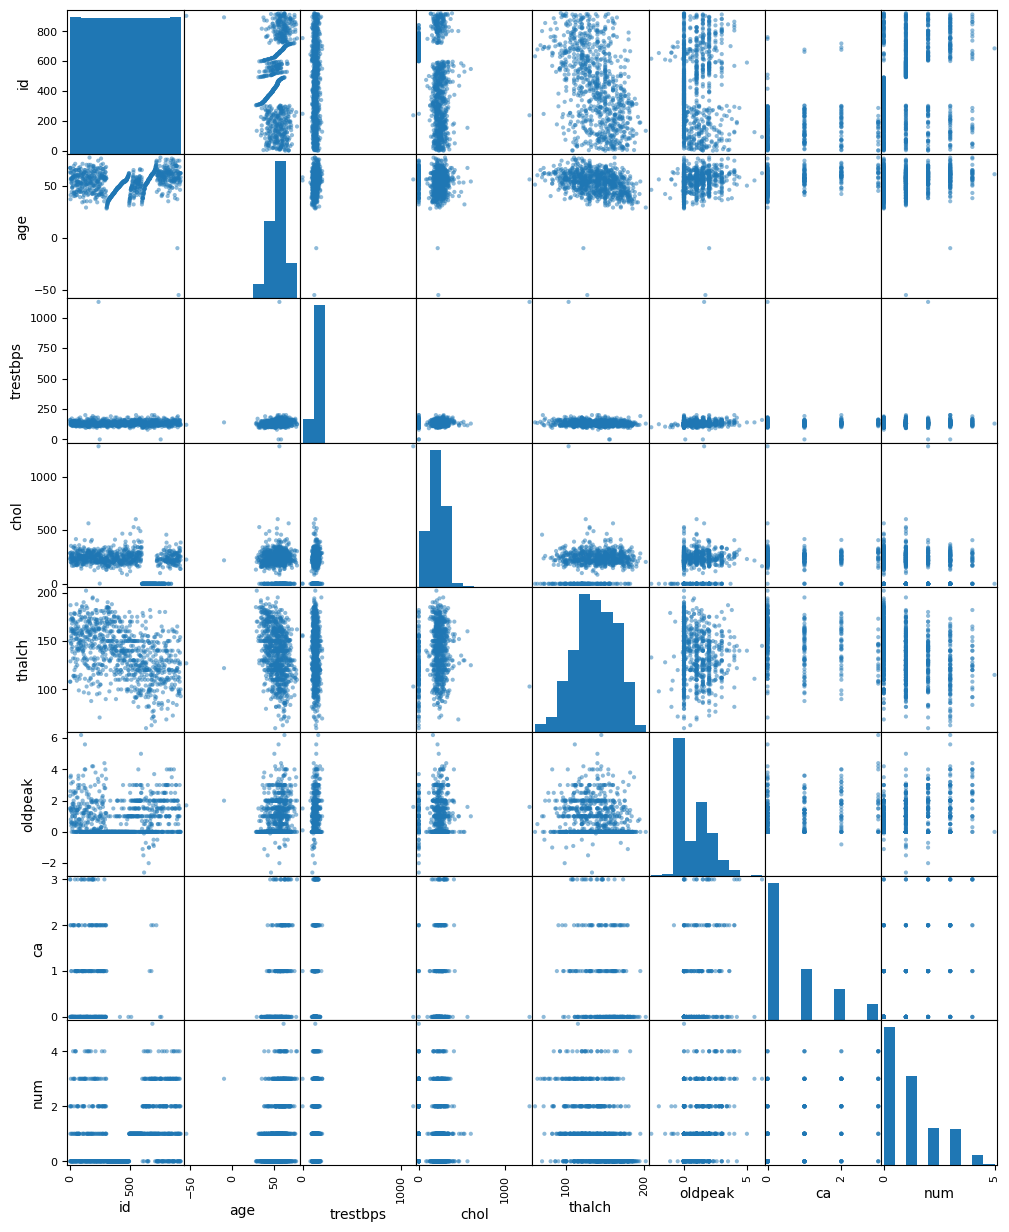

In [ ]:
# Show scatter matrix
scatter_matrix(data,
               figsize= (12, 15),
               diagonal='hist'
)

In [ ]:
# Split X and y
X = data.drop(columns=['num'])
y = data['num']

print("X Shape:\n", X.shape)
print("y Shape:\n", y.shape)

X Shape:
 (922, 15)
y Shape:
 (922,)


In [ ]:
# Check the Dtype of each Feature
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 921
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        922 non-null    int64  
 1   age       922 non-null    int64  
 2   sex       922 non-null    object 
 3   dataset   922 non-null    object 
 4   cp        922 non-null    object 
 5   trestbps  862 non-null    float64
 6   chol      892 non-null    float64
 7   fbs       832 non-null    object 
 8   restecg   920 non-null    object 
 9   thalch    866 non-null    float64
 10  exang     866 non-null    object 
 11  oldpeak   859 non-null    float64
 12  slope     612 non-null    object 
 13  ca        310 non-null    float64
 14  thal      435 non-null    object 
 15  num       922 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.4+ KB


In [ ]:
# Checking counts of each class in 'num'
print(data['num'].value_counts())

num
0    412
1    265
2    110
3    106
4     28
5      1
Name: count, dtype: int64


'num' is highly biased towards 0, which has 412 observations

### Identify Categorical and Numerical Columns
*   categoric_dtype and numerical_dtype variables
*   These variables are used repeatedly throughout this notebook
*   They have been defined here for convenient use throughout

In [ ]:
# Identify categorical and numerical columns
categoric_dtype = ['object']
numerical_dtype = ['int64', 'float64']

### Data Leakage
*   random_state_tracker is defined and set to zero
*   random_state inside train_test_split will be set to random_state_tracker
*   random_state_tracker will increment by +1 before every train_test_split
*   This prevents the respective model from forming bias from leaked test data


In [ ]:
# Define random_state_tracker
random_state_tracker = -1

# Baseline Logistic Regression Model with Minimal Preprocessing

In [ ]:
df_basic = data.copy()

In [ ]:
df_basic

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,918,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
919,919,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
920,920,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


### Drop Missing Values
*   Replace '?' with NaN
*   Convert problematic columns to numeric, errors in parsing result in NaN

https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
*   Drop rows with missing values (generally not encouraged)

In [ ]:
# Replace '?' with NaN
df_basic = df_basic.replace("?", np.nan)

In [ ]:
# Convert problematic columns to numeric
prob_col = ['ca']

for col in prob_col:
  df_basic[col] = pd.to_numeric(df_basic[col], errors='coerce')

In [ ]:
df_basic

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,918,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
919,919,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
920,920,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
# Observing missing values
print(df_basic.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     60
chol         30
fbs          90
restecg       2
thalch       56
exang        56
oldpeak      63
slope       310
ca          612
thal        487
num           0
dtype: int64


In [ ]:
# Drop rows with missing values
df_basic = df_basic.dropna()

In [ ]:
# Verify missing values have been dropped
print(df_basic.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [ ]:
print("Initial Samples:\n", data.shape[0])
print("Samples After Dropping Missing Values:\n", df_basic.shape[0])

Initial Samples:
 922
Samples After Dropping Missing Values:
 300


### Use One-Hot Encoding for Columns/Features containing Categorical Values
*   Create List of Categorical Columns

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.select_dtypes.html
*   One-Hot Encode Categorical Columns

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html



In [ ]:
# Create list of categorical columns for one-hot encoding
categoric_col = df_basic.select_dtypes(
    include=categoric_dtype
).columns.tolist()

In [ ]:
categoric_col

['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [ ]:
# One-hot encode categorical columns
# drop_first=True to address multicollinearity: dummy variable trap
df_basic = pd.get_dummies(df_basic, columns=categoric_col, drop_first=True)

In [ ]:
df_basic.head().T

,0,1,2,3,4
id,0,1,2,3,4
age,63,67,67,67,37
trestbps,145.0,160.0,160.0,120.0,130.0
chol,233.0,286.0,286.0,229.0,250.0
thalch,150.0,108.0,108.0,129.0,187.0
oldpeak,2.3,1.5,1.5,2.6,3.5
ca,0.0,3.0,3.0,2.0,0.0
num,0,2,2,1,0
sex_Male,True,True,True,True,True
dataset_Hungary,False,False,False,False,False


### Separate Columns/Features from Target Column
*   Also drop 'id' to remove noise as column is redundant

In [ ]:
# Split X and y, drop 'id' to remove noise
basic_drop = ['id', 'num']
X_basic = df_basic.drop(columns=basic_drop)
y_basic = df_basic['num']

In [ ]:
print("X_basic Shape:\n", X_basic.shape)
print("y_basic Shape:\n", y_basic.shape)

X_basic Shape:
 (300, 20)
y_basic Shape:
 (300,)


### Baseline Logistic Regression Model
*   solver='liblinear', as solver='lbfgs' failed to converge at 1000+ iterations



In [ ]:
# Split data: 80% training, 20% test
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_basic,
    y_basic,
    test_size=0.2,
    stratify=y_basic,
    random_state=random_state_tracker
)

random_state used:
 0


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (240, 20)
y_train: (240,)


X_test: (60, 20)
y_test: (60,)


In [ ]:
# Train model
# lbfgs failed to converge at 1000 iterations
lr_basic = LogisticRegression(solver='liblinear', max_iter=1000)
lr_basic.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_basic.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Baseline (Multiclass):")
print(f"Train Score: {lr_basic.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_basic.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Baseline (Multiclass):
Train Score: 0.6667
Test Score: 0.4833


In [ ]:
# Evaluate model
print("Logistic Regression - Baseline - Results:\n")
print(f"Accuracy: {lr_basic.score(X_test, y_test):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Baseline - Results:

Accuracy: 0.4833

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.91      0.81        32
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00         3

    accuracy                           0.48        60
   macro avg       0.14      0.18      0.16        60
weighted avg       0.39      0.48      0.43        60


Confusion Matrix:

[[29  3  0  0  0]
 [ 8  0  2  1  0]
 [ 2  3  0  2  0]
 [ 1  5  1  0  0]
 [ 0  0  2  1  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Treat Baseline Model as Binary
*   Model flawed due to high bias of Class 0 in Target
*   Treat 'num' as Binary to mitigate this


In [ ]:
# Checking counts of each class in 'num'
print(df_basic['num'].value_counts())

num
0    160
1     56
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
# Make 'num' binary: 0 = no disease; 1 = disease
df_basic['num'] = df_basic['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Verify target is now binary
print(df_basic['num'].value_counts())

num
0    160
1    140
Name: count, dtype: int64


In [ ]:
X_basic = df_basic.drop(columns=basic_drop)
y_basic = df_basic['num']

In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_basic,
    y_basic,
    test_size=0.2,
    stratify=y_basic,
    random_state=random_state_tracker
)

random_state used:
 1


In [ ]:
# Train model
lr_basic = LogisticRegression(solver='liblinear', max_iter=1000)
lr_basic.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_basic.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Baseline (Binary)")
print(f"Train Score: {lr_basic.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_basic.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Baseline (Binary)
Train Score: 0.8750
Test Score: 0.8667


In [ ]:
# Evaluate model
print("Baseline Logistic Regression Results (Binary):\n")
print(f"Accuracy: {lr_basic.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Baseline Logistic Regression Results (Binary):

Accuracy: 0.8667

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60


Confusion Matrix:

[[29  3]
 [ 5 23]]


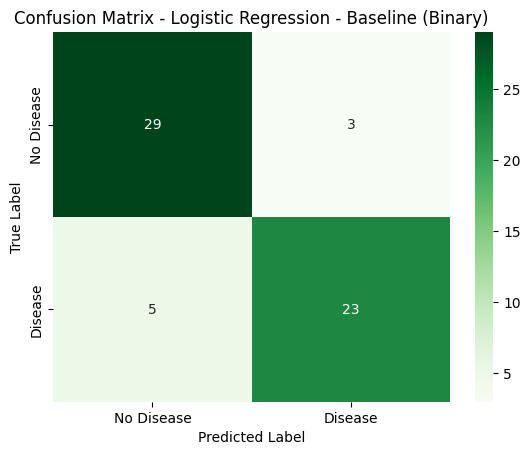

In [ ]:
# Visualise confusion matrix
cm_basic = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_basic,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[
        'No Disease',
        'Disease'
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression - Baseline (Binary)")
plt.show()

# Data Cleaning and Preprocessing (Multiclass)

### Rebuild Baseline Model 'df_basic' but Correctly:
*   'df_drop_duplicates' - Drop Duplicate Values
*   'df_imputed' - Missing Values Imputed instead of Dropped in Baseline Model
*   'df_encoded' - One-Hot Encoded

In [ ]:
df = data.copy()

In [ ]:
# Drop 'id' column: redundant & interfers with duplicate value detection
df = df.drop(columns=['id'])

In [ ]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0


In [ ]:
# Dropping missing values caused a lot of data loss
print("Dataset (baseline) Shape:\n", df_basic.shape)
print("Dataset Shape:\n", df.shape)

Dataset (baseline) Shape:
 (300, 22)
Dataset Shape:
 (922, 15)


In [ ]:
# Descriptive statistics
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,922.000000,862.000000,892.000000,866.000000,859.000000,310.000000,922.000000
mean,53.331887,133.208817,200.021300,137.511547,0.879511,0.683871,0.997831
std,10.287846,39.222443,116.659406,25.930730,1.090796,0.943414,1.148097
min,-55.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,77.000000,1130.000000,1283.000000,202.000000,6.200000,3.000000,5.000000


In [ ]:
# Check the number of unique values for each column/feature
df.nunique()

,0
age,52
sex,2
dataset,4
cp,4
trestbps,62
chol,219
fbs,2
restecg,3
thalch,119
exang,2


In [ ]:
# Check the Dtype of each Feature
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 921
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       922 non-null    int64  
 1   sex       922 non-null    object 
 2   dataset   922 non-null    object 
 3   cp        922 non-null    object 
 4   trestbps  862 non-null    float64
 5   chol      892 non-null    float64
 6   fbs       832 non-null    object 
 7   restecg   920 non-null    object 
 8   thalch    866 non-null    float64
 9   exang     866 non-null    object 
 10  oldpeak   859 non-null    float64
 11  slope     612 non-null    object 
 12  ca        310 non-null    float64
 13  thal      435 non-null    object 
 14  num       922 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 108.2+ KB


In [ ]:
# Check for duplicates
duplicate_samples = df.duplicated().sum()
print("Duplicate Samples:", duplicate_samples)

Duplicate Samples: 4


In [ ]:
# Check for missing data
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

age           0
sex           0
dataset       0
cp            0
trestbps     60
chol         30
fbs          90
restecg       2
thalch       56
exang        56
oldpeak      63
slope       310
ca          612
thal        487
num           0
dtype: int64


### Drop Duplicated Values

In [ ]:
# Deduct/Remove duplicate samples
df_dedup = df.drop_duplicates()

In [ ]:
print("Shape after Removing Duplicate Samples:", df_dedup.shape)

Shape after Removing Duplicate Samples: (918, 15)


### Impute Missing Values

In [ ]:
df_imputed = df_dedup.copy()

In [ ]:
# Identify categorical and numerical columns
categoric_col = df_imputed.select_dtypes(
    include=categoric_dtype
).columns.tolist()

numeric_col = df_imputed.select_dtypes(
    include=numerical_dtype
).columns.tolist()

In [ ]:
print("Categorical Columns:\n", categoric_col)
print("Numerical Columns:\n", numeric_col)

Categorical Columns:
 ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Columns:
 ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']


In [ ]:
# Impute categorical columns using the mode
categorical_imputer = SimpleImputer(strategy='most_frequent')

df_imputed[categoric_col] =  categorical_imputer.fit_transform(
    df_imputed[categoric_col]
)

print("Categorical Columns Imputed: \n", df_imputed[categoric_col])

Categorical Columns Imputed: 
         sex        dataset               cp    fbs           restecg  exang  \
0      Male      Cleveland   typical angina   True    lv hypertrophy  False   
1      Male      Cleveland     asymptomatic  False    lv hypertrophy   True   
3      Male      Cleveland     asymptomatic  False    lv hypertrophy   True   
4      Male      Cleveland      non-anginal  False            normal  False   
5    Female      Cleveland  atypical angina  False    lv hypertrophy  False   
..      ...            ...              ...    ...               ...    ...   
916  Female  VA Long Beach     asymptomatic   True  st-t abnormality  False   
917    Male  VA Long Beach   typical angina  False  st-t abnormality  False   
919    Male  VA Long Beach     asymptomatic   True  st-t abnormality  False   
920    Male  VA Long Beach     asymptomatic   True    lv hypertrophy  False   
921    Male  VA Long Beach  atypical angina  False    lv hypertrophy   True   

           slope    

In [ ]:
# Impute numerical columns using the median
numerical_imputer = SimpleImputer(strategy='median')

df_imputed[numeric_col] = numerical_imputer.fit_transform(
    df_imputed[numeric_col]
)

print("Numerical Columns Imputed:\n", df_imputed[numeric_col])

Numerical Columns Imputed:
       age  trestbps   chol  thalch  oldpeak   ca  num
0    63.0     145.0  233.0   150.0      2.3  0.0  0.0
1    67.0     160.0  286.0   108.0      1.5  3.0  2.0
3    67.0     120.0  229.0   129.0      2.6  2.0  1.0
4    37.0     130.0  250.0   187.0      3.5  0.0  0.0
5    41.0     130.0  204.0   172.0      1.4  0.0  0.0
..    ...       ...    ...     ...      ...  ...  ...
916  54.0     127.0  333.0   154.0      0.0  0.0  1.0
917  62.0     130.0  139.0   140.0      0.5  0.0  0.0
919  55.0     122.0  223.0   100.0      0.0  0.0  2.0
920  58.0     130.0  385.0   140.0      0.5  0.0  0.0
921  62.0     120.0  254.0    93.0      0.0  0.0  1.0

[918 rows x 7 columns]


In [ ]:
# Verify that missing values have been imputed
print(df_imputed.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


### Encode Categorical Values

In [ ]:
df_encoded = df_imputed.copy()

In [ ]:
# Obtain Categoric Columns
categoric_col = df_encoded.select_dtypes(
    include=categoric_dtype
).columns.tolist()

print("Categorical Columns\n:", categoric_col)

Categorical Columns
: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [ ]:
# One-hot encode categorical columns
# drop_first=True to address multicollinearity: dummy variable trap
df_encoded = pd.get_dummies(df_encoded, columns=categoric_col, drop_first=True)

In [ ]:
df_encoded.head().T

,0,1,3,4,5
age,63.0,67.0,67.0,37.0,41.0
trestbps,145.0,160.0,120.0,130.0,130.0
chol,233.0,286.0,229.0,250.0,204.0
thalch,150.0,108.0,129.0,187.0,172.0
oldpeak,2.3,1.5,2.6,3.5,1.4
ca,0.0,3.0,2.0,0.0,0.0
num,0.0,2.0,1.0,0.0,0.0
sex_Male,True,True,True,True,False
dataset_Hungary,False,False,False,False,False
dataset_Switzerland,False,False,False,False,False


In [ ]:
print("Shape Before One-Hot Encoding:\n", df_imputed.shape)

print("Shape After One-Hot Encoding\n", df_encoded.shape)

Shape Before One-Hot Encoding:
 (918, 15)
Shape After One-Hot Encoding
 (918, 22)


### Baseline Model has been rebuilt with Improved Preprocessing Methods: 'df_encoded'

*   Run Improved Baseline Model and Observe any Improvements



In [ ]:
# Split X and y
X_encoded = df_encoded.drop(columns=['num'])
y_encoded = df_encoded['num']

In [ ]:
print("X_encoded Shape:\n", X_encoded.shape)
print("y_encoded Shape:\n", y_encoded.shape)

X_encoded Shape:
 (918, 21)
y_encoded Shape:
 (918,)


In [ ]:
# Split data:
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=random_state_tracker
)

random_state used:
 2


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
# Split failed, revert random_state_tracker to previous value
random_state_tracker -= 1
print("random_state_tracker Current:\n", random_state_tracker)

random_state_tracker Current:
 1


In [ ]:
# Checking for problematic class
y_encoded.value_counts()

,count
num,
0.0,410
1.0,265
2.0,108
3.0,106
4.0,28
5.0,1


In [ ]:
# Observing problematic sample
df_encoded[df_encoded['num'] == 5.0]

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
685,61.0,130.0,0.0,115.0,0.0,0.0,5.0,True,False,True,...,False,False,False,False,False,False,True,False,False,True


### Problematic Sample
*   Multiclass Approach: Remove Problematic Sample
*   Binary Approach: Binarise Target



In [ ]:
# Copy DataFrame, excluding problematic sample
df_encoded_drop5 = df_encoded[df_encoded['num'] != 5.0].copy()

In [ ]:
print("df_encoded_drop5 Shape:\n", df_encoded_drop5.shape)

df_encoded_drop5 Shape:
 (917, 22)


In [ ]:
# Split X and y again
X_encoded_drop5 = df_encoded_drop5.drop(columns=['num'])
y_encoded_drop5 = df_encoded_drop5['num']

In [ ]:
print("X_encoded_drop5 Shape:\n", X_encoded_drop5.shape)
print("y_encoded_drop5 Shape:\n", y_encoded_drop5.shape)

X_encoded_drop5 Shape:
 (917, 21)
y_encoded_drop5 Shape:
 (917,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_drop5,
    y_encoded_drop5,
    test_size=0.2,
    stratify=y_encoded_drop5,
    random_state=random_state_tracker
)

random_state used:
 2


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (733, 21)
y_train: (733,)


X_test: (184, 21)
y_test: (184,)


### Train Model: First Attempt 'lbfgs' as it failed to converge in Baseline Model

In [ ]:
# Train model
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# Train model
# lbfgs failed to converge at 1000 iterations
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary Logistic Regression - Improved Baseline (Multiclass):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary Logistic Regression - Improved Baseline (Multiclass):
Train Score: 0.6289
Test Score: 0.5761


In [ ]:
# Evaluate model
print("Logistic Regression - Improved Baseline - Results (Multiclass):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Improved Baseline - Results (Multiclass):

Accuracy: 0.5761

Classification Report:

              precision    recall  f1-score   support

         0.0       0.72      0.87      0.79        82
         1.0       0.53      0.58      0.56        53
         2.0       0.00      0.00      0.00        22
         3.0       0.20      0.19      0.20        21
         4.0       0.00      0.00      0.00         6

    accuracy                           0.58       184
   macro avg       0.29      0.33      0.31       184
weighted avg       0.50      0.58      0.53       184


Confusion Matrix:

[[71  8  0  3  0]
 [17 31  1  4  0]
 [ 8  7  0  7  0]
 [ 2  9  4  4  2]
 [ 0  3  1  2  0]]


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression - Improved Baseline (Multiclass)')

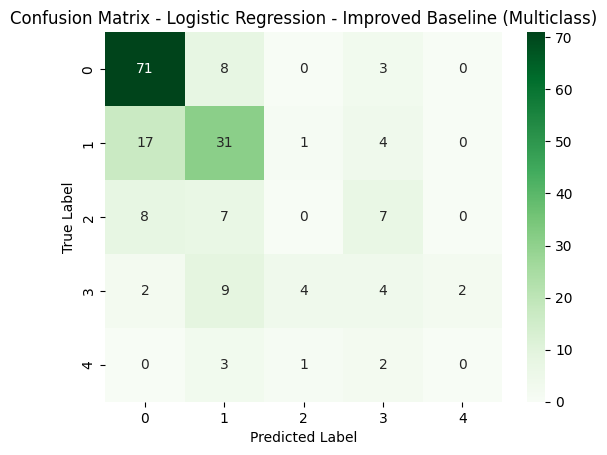

In [ ]:
# Visualise confusion matrix
cm_multi = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "Confusion Matrix - Logistic Regression - Improved Baseline (Multiclass)"
)

### Remove Outliers (Multiclass)
*   Using LocalOutlierFactor to detect outliers

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html

In [ ]:
df_outlier_removed_multi = df_encoded_drop5.copy()

In [ ]:
# Exclude 'num' from features/columns as it is the target
X_lof = df_outlier_removed_multi.drop(columns=['num'])

In [ ]:
# Use LocalOutlierFactor to detect/predict outliers
lof = LocalOutlierFactor()
yhat = lof.fit_predict(X_lof)

In [ ]:
# Observe outlier samples
df_outlier_multi = df_outlier_removed_multi[yhat == -1]
df_outlier_multi

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
153,67.0,115.0,564.0,160.0,1.6,0.0,0.0,False,False,False,...,True,False,False,False,False,False,True,False,False,True
189,54.0,192.0,283.0,195.0,0.0,1.0,1.0,True,False,False,...,False,False,False,False,False,False,False,True,False,True
237,56.0,1130.0,1283.0,103.0,1.6,0.0,2.0,True,False,False,...,False,False,True,False,False,True,False,False,False,True
247,58.0,0.0,2.0,156.0,0.1,1.0,2.0,True,False,False,...,False,False,False,True,False,False,False,True,False,True
339,39.0,190.0,241.0,106.0,0.0,0.0,0.0,True,True,False,...,False,False,False,True,False,False,True,False,True,False
376,45.0,180.0,223.0,180.0,0.0,0.0,0.0,False,True,False,...,False,False,False,True,False,False,True,False,True,False
432,52.0,140.0,100.0,138.0,0.0,0.0,0.0,True,True,False,...,False,False,False,True,False,True,True,False,True,False
435,53.0,113.0,468.0,127.0,0.0,0.0,0.0,False,True,False,...,False,False,False,True,False,False,True,False,True,False
474,56.0,120.0,85.0,140.0,0.0,0.0,0.0,True,True,False,...,False,False,False,True,False,False,True,False,True,False
500,38.0,92.0,117.0,134.0,2.5,0.0,1.0,True,True,False,...,False,False,False,True,False,True,True,False,True,False


In [ ]:
print("Number of Samples:\n", df_outlier_removed_multi.shape[0])
print("Number of Detected Outliers:\n", df_outlier_multi.shape[0])

Number of Samples:
 917
Number of Detected Outliers:
 27


In [ ]:
# Remove outliers
df_outlier_removed_multi = df_outlier_removed_multi[yhat == 1]

In [ ]:
print("Number of Remaining Samples:\n", df_outlier_removed_multi.shape[0])

Number of Remaining Samples:
 890


### Visualise Outliers
*   Use Principal Component Analysis to reduce dimensionality for Visualisation

https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
# Reduce dimensionality to 2 for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lof)

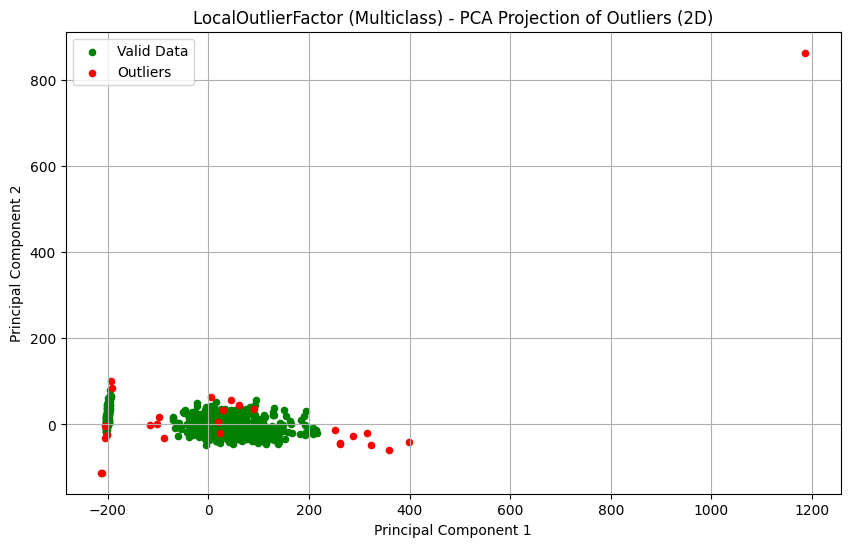

In [ ]:
# Visualise outliers
plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[yhat == 1, 0],
    X_pca[yhat == 1, 1],
    label='Valid Data',
    c='green',
    s=20
)

plt.scatter(
    X_pca[yhat == -1, 0],
    X_pca[yhat == -1, 1],
    label='Outliers',
    c='red',
    s=20
)

plt.title(
    'LocalOutlierFactor (Multiclass) - PCA Projection of Outliers (2D)'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Logistic Regression Model after Removing Outliers (Multiclass)

In [ ]:
# Split X and y
X_outlier_removed_multi = df_outlier_removed_multi.drop(columns=['num'])
y_outlier_removed_multi = df_outlier_removed_multi['num']

In [ ]:
print("X_outlier_removed_multi Shape:\n", X_outlier_removed_multi.shape)
print("y_outlier_removed_multi Shape:\n", y_outlier_removed_multi.shape)

X_outlier_removed_multi Shape:
 (890, 21)
y_outlier_removed_multi Shape:
 (890,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_outlier_removed_multi,
    y_outlier_removed_multi,
    test_size=0.2,
    stratify=y_outlier_removed_multi,
    random_state=random_state_tracker
)

random_state used:
 3


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (712, 21)
y_train: (712,)


X_test: (178, 21)
y_test: (178,)


In [ ]:
# Train model
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Outliers Removed (Multiclass):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Outliers Removed (Multiclass):
Train Score: 0.6194
Test Score: 0.5955


In [ ]:
# Evaluate model
print("Logistic Regression - Outliers Removed - Results (Multiclass):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Outliers Removed - Results (Multiclass):

Accuracy: 0.5955

Classification Report:

              precision    recall  f1-score   support

         0.0       0.76      0.88      0.81        80
         1.0       0.49      0.59      0.54        51
         2.0       0.11      0.05      0.07        21
         3.0       0.31      0.25      0.28        20
         4.0       0.00      0.00      0.00         6

    accuracy                           0.60       178
   macro avg       0.34      0.35      0.34       178
weighted avg       0.53      0.60      0.56       178


Confusion Matrix:

[[70  6  3  1  0]
 [16 30  3  2  0]
 [ 1 11  1  8  0]
 [ 4  9  2  5  0]
 [ 1  5  0  0  0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression - Outliers Removed (Multiclass)')

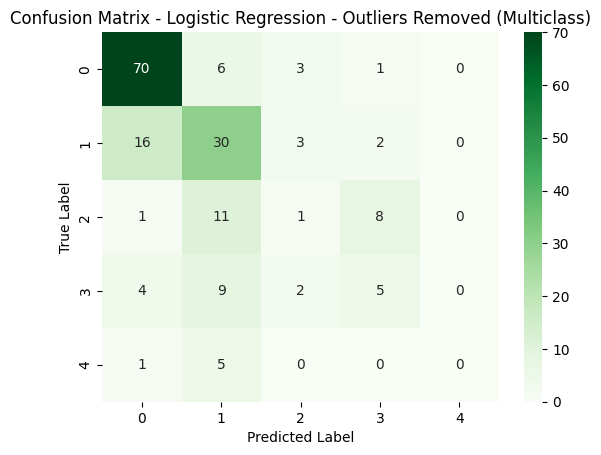

In [ ]:
# Visualise confusion matrix
cm_multi = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "Confusion Matrix - Logistic Regression - Outliers Removed (Multiclass)"
)

### Scale Numerical Features using StandardScaler (Multiclass)


*   Scale Numerical Features

https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

*   Update Numerical Features with Scaled Features

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.update.html
*   Join 'num' back to the DataFrame

https://pandas.pydata.org/docs/reference/api/pandas.concat.html



In [ ]:
df_scaled_multi = df_outlier_removed_multi.copy()

In [ ]:
# Split X and y as 'num' is target
X = df_scaled_multi.drop(columns=['num'])
y = df_scaled_multi['num']

In [ ]:
# Select numerical columns/features
numeric_col = X.select_dtypes(
    include=numerical_dtype
).columns.tolist()

In [ ]:
# View the columns that are to be scaled
print("Numerical Columns:\n", X[numeric_col])

Numerical Columns:
       age  trestbps   chol  thalch  oldpeak   ca
0    63.0     145.0  233.0   150.0      2.3  0.0
1    67.0     160.0  286.0   108.0      1.5  3.0
3    67.0     120.0  229.0   129.0      2.6  2.0
4    37.0     130.0  250.0   187.0      3.5  0.0
5    41.0     130.0  204.0   172.0      1.4  0.0
..    ...       ...    ...     ...      ...  ...
916  54.0     127.0  333.0   154.0      0.0  0.0
917  62.0     130.0  139.0   140.0      0.5  0.0
919  55.0     122.0  223.0   100.0      0.0  0.0
920  58.0     130.0  385.0   140.0      0.5  0.0
921  62.0     120.0  254.0    93.0      0.0  0.0

[890 rows x 6 columns]


In [ ]:
# Scale numerical columns/features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numeric_col])

In [ ]:
# Create DataFrame from scaled values
df_X_scaled_multi = pd.DataFrame(
    X_scaled,
    columns=numeric_col,
    index=X.index
)

In [ ]:
# Update numerical columns/features with scaled features
X.update(df_X_scaled_multi)

In [ ]:
# Add 'num' target column back into DataFrame
df_clean_multi = pd.concat([X, y], axis=1)

# Final Clean Dataset (Multiclass)

In [ ]:
print("Original Dataset:\n")
data

Original Dataset:



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,918,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
919,919,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
920,920,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
print("Cleaned Dataset (Multiclass):\n")
df_clean_multi

Cleaned Dataset (Multiclass):



,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,num
0,1.001893,0.760977,0.327509,0.485300,1.357502,-0.365266,True,False,False,False,...,True,True,False,False,False,False,False,False,False,0.0
1,1.424692,1.638422,0.832994,-1.202191,0.605739,4.346133,True,False,False,False,...,False,False,False,False,True,True,False,True,False,2.0
3,1.424692,-0.701430,0.289360,-0.358445,1.639413,2.775667,True,False,False,False,...,False,False,False,False,True,True,False,False,True,1.0
4,-1.746305,-0.116467,0.489646,1.971899,2.485146,-0.365266,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0.0
5,-1.323505,-0.116467,0.050924,1.369224,0.511769,-0.365266,False,False,False,False,...,False,False,False,False,False,False,True,True,False,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,0.050593,-0.291956,1.281254,0.646014,-0.803816,-0.365266,False,False,False,True,...,False,True,False,True,False,True,False,True,False,1.0
917,0.896193,-0.116467,-0.569010,0.083517,-0.333964,-0.365266,True,False,False,True,...,True,False,False,True,False,True,False,True,False,0.0
919,0.156293,-0.584437,0.232135,-1.523617,-0.803816,-0.365266,True,False,False,True,...,False,True,False,True,False,True,False,False,False,2.0
920,0.473393,-0.116467,1.777201,0.083517,-0.333964,-0.365266,True,False,False,True,...,False,True,False,False,False,True,False,True,False,0.0


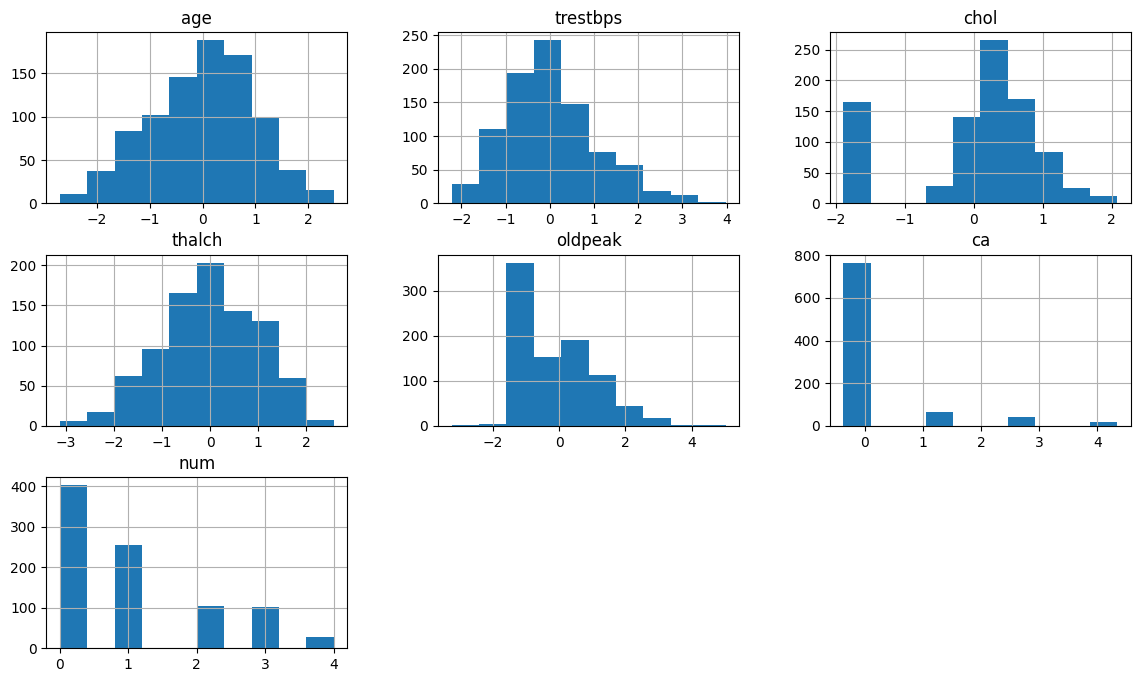

In [ ]:
# Visualise numerical features
df_clean_multi.hist(figsize=(14,8))
plt.show()

After cleaning, the 'ca' Feature appears show a lot of bias for 0

### Run Logistic Regression on Cleaned Dataset (Multiclass)

In [ ]:
# Split X and y
X_clean_multi = df_clean_multi.drop(columns=['num'])
y_clean_multi = df_clean_multi['num']

In [ ]:
print("X_clean_multi Shape:\n", X_clean_multi.shape)
print("y_clean_multi Shape:\n", y_clean_multi.shape)

X_clean_multi Shape:
 (890, 21)
y_clean_multi Shape:
 (890,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean_multi,
    y_clean_multi,
    test_size=0.2,
    stratify=y_clean_multi,
    random_state=random_state_tracker
)

random_state used:
 4


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (712, 21)
y_train: (712,)


X_test: (178, 21)
y_test: (178,)


In [ ]:
# Train model
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Cleaned Dataset (Multiclass):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Cleaned Dataset (Multiclass):
Train Score: 0.6124
Test Score: 0.5843


In [ ]:
# Evaluate model
print("Logistic Regression - Cleaned Dataset - Results (Multiclass):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Cleaned Dataset - Results (Multiclass):

Accuracy: 0.5843

Classification Report:

              precision    recall  f1-score   support

         0.0       0.71      0.90      0.80        80
         1.0       0.47      0.55      0.51        51
         2.0       0.29      0.10      0.14        21
         3.0       0.20      0.10      0.13        20
         4.0       0.00      0.00      0.00         6

    accuracy                           0.58       178
   macro avg       0.33      0.33      0.32       178
weighted avg       0.51      0.58      0.54       178


Confusion Matrix:

[[72  7  1  0  0]
 [19 28  2  2  0]
 [ 4 12  2  3  0]
 [ 6  9  2  2  1]
 [ 0  3  0  3  0]]


Text(0.5, 1.0, 'Confusion Matrix - Logistic Regression - Cleaned Dataset (Multiclass)')

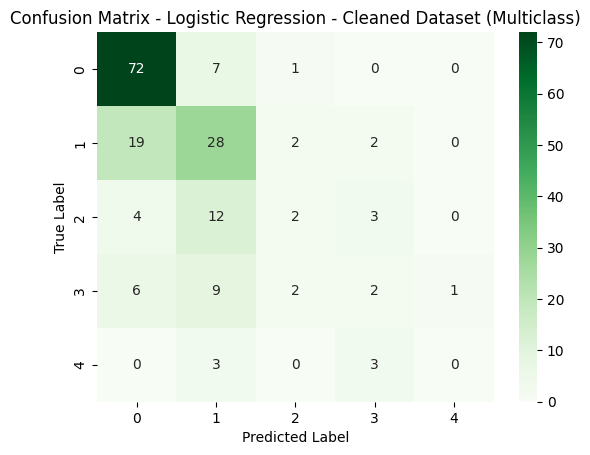

In [ ]:
# Visualise confusion matrix
cm_multi = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "Confusion Matrix - Logistic Regression - Cleaned Dataset (Multiclass)"
)

Model performs slightly worse after scaling
*   Suggests importance in the magnitude of certain features
*   This information may be lost after scaling



# Data Cleaning and Preprocessing (Binary)
*   It appears that scaling the data lowered the test score, so the best results for Multiclass classification are obtained after removing outliers
*   We can approach the problem as Binary instead of Multiclass (as we did in the baseline model) to observe the effects of preprocessing
*   This will improve the performance of the model, as Class 0 dominates and causes a lot of bias in the Multiclass appraoch (as seen in the various classification reports and confusion matrices)







In [ ]:
# Start with df_encoded (this was the improved baseline model)
df_encoded_bin = df_encoded.copy()

print("Encoded Dataset (Multiclass):\n")
df_encoded

Encoded Dataset (Multiclass):



,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,0.0,True,False,False,...,False,True,True,False,False,False,False,False,False,False
1,67.0,160.0,286.0,108.0,1.5,3.0,2.0,True,False,False,...,False,False,False,False,False,True,True,False,True,False
3,67.0,120.0,229.0,129.0,2.6,2.0,1.0,True,False,False,...,False,False,False,False,False,True,True,False,False,True
4,37.0,130.0,250.0,187.0,3.5,0.0,0.0,True,False,False,...,True,False,False,True,False,False,False,False,True,False
5,41.0,130.0,204.0,172.0,1.4,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,54.0,127.0,333.0,154.0,0.0,0.0,1.0,False,False,False,...,False,False,True,False,True,False,True,False,True,False
917,62.0,130.0,139.0,140.0,0.5,0.0,0.0,True,False,False,...,False,True,False,False,True,False,True,False,True,False
919,55.0,122.0,223.0,100.0,0.0,0.0,2.0,True,False,False,...,False,False,True,False,True,False,True,False,False,False
920,58.0,130.0,385.0,140.0,0.5,0.0,0.0,True,False,False,...,False,False,True,False,False,False,True,False,True,False


In [ ]:
# Encode 'num' for binary classification: 0 = no disease; 1 = disease
df_encoded_bin['num'] = df_encoded_bin['num'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
print("Encoded Dataset (Binary):\n")
df_encoded_bin

Encoded Dataset (Binary):



,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,0,True,False,False,...,False,True,True,False,False,False,False,False,False,False
1,67.0,160.0,286.0,108.0,1.5,3.0,1,True,False,False,...,False,False,False,False,False,True,True,False,True,False
3,67.0,120.0,229.0,129.0,2.6,2.0,1,True,False,False,...,False,False,False,False,False,True,True,False,False,True
4,37.0,130.0,250.0,187.0,3.5,0.0,0,True,False,False,...,True,False,False,True,False,False,False,False,True,False
5,41.0,130.0,204.0,172.0,1.4,0.0,0,False,False,False,...,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,54.0,127.0,333.0,154.0,0.0,0.0,1,False,False,False,...,False,False,True,False,True,False,True,False,True,False
917,62.0,130.0,139.0,140.0,0.5,0.0,0,True,False,False,...,False,True,False,False,True,False,True,False,True,False
919,55.0,122.0,223.0,100.0,0.0,0.0,1,True,False,False,...,False,False,True,False,True,False,True,False,False,False
920,58.0,130.0,385.0,140.0,0.5,0.0,0,True,False,False,...,False,False,True,False,False,False,True,False,True,False


In [ ]:
# Verify that 'num' is now binary
df_encoded_bin['num'].value_counts()

,count
num,
1,508
0,410


Data is now not heavily biased towards class 0

### Logistic Regression Model (Improved Baseline Model - Binary)

In [ ]:
# Split X and y
X_encoded_bin = df_encoded_bin.drop(columns=['num'])
y_encoded_bin = df_encoded_bin['num']

In [ ]:
print("X_encoded_bin Shape:\n", X_encoded_bin.shape)
print("y_encoded_bin Shape:\n", y_encoded_bin.shape)

X_encoded_bin Shape:
 (918, 21)
y_encoded_bin Shape:
 (918,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_bin,
    y_encoded_bin,
    test_size=0.2,
    stratify=y_encoded_bin,
    random_state=random_state_tracker
)

random_state used:
 5


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (734, 21)
y_train: (734,)


X_test: (184, 21)
y_test: (184,)


In [ ]:
# Train model
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Improved Baseline (Binary):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Improved Baseline (Binary):
Train Score: 0.8365
Test Score: 0.8370


In [ ]:
# Evaluate model
print("Logistic Regression - Improved Baseline - Results (Binary):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Improved Baseline - Results (Binary):

Accuracy: 0.8370

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.82        82
           1       0.88      0.82      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:

[[70 12]
 [18 84]]


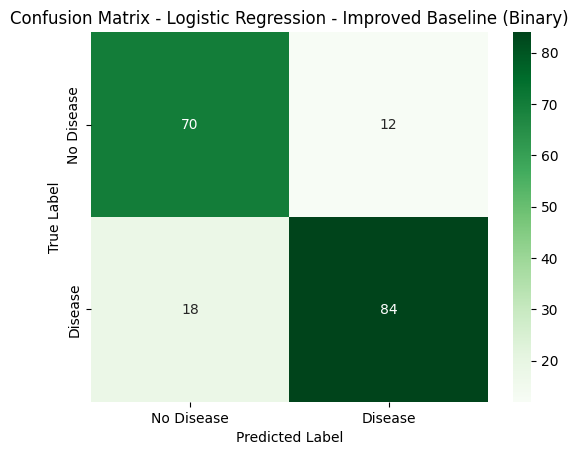

In [ ]:
# Visualise confusion matrix
cm_bin = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_bin,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[
        'No Disease',
        'Disease'
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression - Improved Baseline (Binary)")
plt.show()

Appears to perform slightly worse than the Baseline Binary Model, however this is still better as:
*   Missing Values are Imputed, instead of just being dropped
*   As a result, this is a larger scale dataset, so accuracy fine considering

### Remove Outliers (Binary)

In [ ]:
df_outlier_removed_bin = df_encoded_bin.copy()

In [ ]:
# Exclude 'num' from features/columns as it is the target
X_lof = df_outlier_removed_bin.drop(columns=['num'])

In [ ]:
# Use LocalOutlierFactor to detect/predict outliers
lof = LocalOutlierFactor()
yhat = lof.fit_predict(X_lof)

In [ ]:
# Observe outlier samples
df_outlier_bin = df_outlier_removed_bin[yhat == -1]
df_outlier_bin

,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,dataset_Switzerland,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
153,67.0,115.0,564.0,160.0,1.6,0.0,0,False,False,False,...,True,False,False,False,False,False,True,False,False,True
189,54.0,192.0,283.0,195.0,0.0,1.0,1,True,False,False,...,False,False,False,False,False,False,False,True,False,True
237,56.0,1130.0,1283.0,103.0,1.6,0.0,1,True,False,False,...,False,False,True,False,False,True,False,False,False,True
247,58.0,0.0,2.0,156.0,0.1,1.0,1,True,False,False,...,False,False,False,True,False,False,False,True,False,True
339,39.0,190.0,241.0,106.0,0.0,0.0,0,True,True,False,...,False,False,False,True,False,False,True,False,True,False
376,45.0,180.0,223.0,180.0,0.0,0.0,0,False,True,False,...,False,False,False,True,False,False,True,False,True,False
432,52.0,140.0,100.0,138.0,0.0,0.0,0,True,True,False,...,False,False,False,True,False,True,True,False,True,False
435,53.0,113.0,468.0,127.0,0.0,0.0,0,False,True,False,...,False,False,False,True,False,False,True,False,True,False
474,56.0,120.0,85.0,140.0,0.0,0.0,0,True,True,False,...,False,False,False,True,False,False,True,False,True,False
500,38.0,92.0,117.0,134.0,2.5,0.0,1,True,True,False,...,False,False,False,True,False,True,True,False,True,False


In [ ]:
print("Number of Samples:\n", df_outlier_removed_bin.shape[0])
print("Number of Detected Outliers:\n", df_outlier_bin.shape[0])

Number of Samples:
 918
Number of Detected Outliers:
 27


In [ ]:
# Remove outliers
df_outlier_removed_bin = df_outlier_removed_bin[yhat == 1]

In [ ]:
print("Number of Remaining Samples:\n", df_outlier_removed_bin.shape[0])

Number of Remaining Samples:
 891


### Visualise Outliers (Binary)

In [ ]:
# Reduce dimensionality to 2 for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lof)

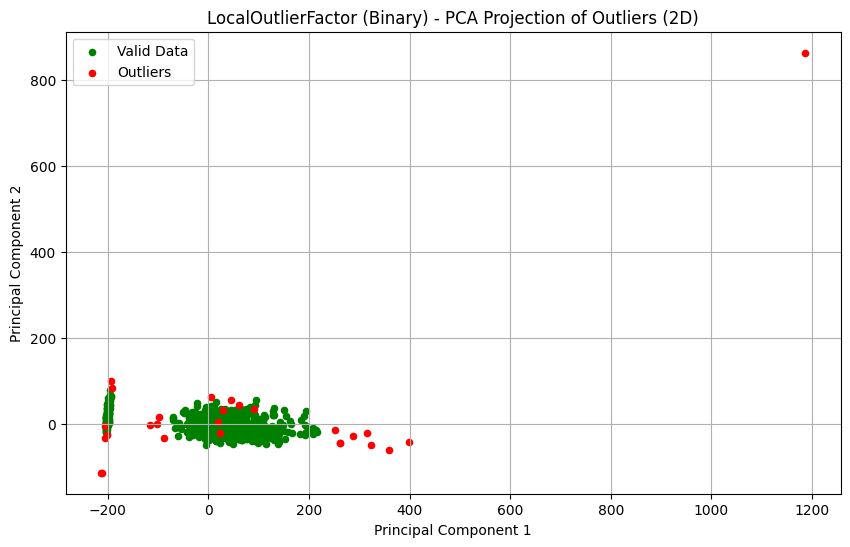

In [ ]:
# Visualise outliers
plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca[yhat == 1, 0],
    X_pca[yhat == 1, 1],
    label='Valid Data',
    c='green',
    s=20
)

plt.scatter(
    X_pca[yhat == -1, 0],
    X_pca[yhat == -1, 1],
    label='Outliers',
    c='red',
    s=20
)

plt.title(
    'LocalOutlierFactor (Binary) - PCA Projection of Outliers (2D)'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

Same as Visualisation for Multiclass as 'num' is removed:
*   'num' is the Target that is changed by Binarisation



### Logistic Regression Model after Removing Outliers (Binary)

In [ ]:
# Split X and y
X_outlier_removed_bin = df_outlier_removed_bin.drop(columns=['num'])
y_outlier_removed_bin = df_outlier_removed_bin['num']

In [ ]:
print("X_outlier_removed_bin Shape:\n", X_outlier_removed_bin.shape)
print("y_outlier_removed_bin Shape:\n", y_outlier_removed_bin.shape)

X_outlier_removed_bin Shape:
 (891, 21)
y_outlier_removed_bin Shape:
 (891,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_outlier_removed_bin,
    y_outlier_removed_bin,
    test_size=0.2,
    stratify=y_outlier_removed_bin,
    random_state=random_state_tracker
)

random_state used:
 6


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (712, 21)
y_train: (712,)


X_test: (179, 21)
y_test: (179,)


In [ ]:
# Train model
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Outliers Removed (Binary):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Outliers Removed (Binary):
Train Score: 0.8413
Test Score: 0.8268


In [ ]:
# Evaluate model
print("Logistic Regression - Outliers Removed - Results (Binary):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Outliers Removed - Results (Binary):

Accuracy: 0.8268

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.81      0.81        81
           1       0.85      0.84      0.84        98

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179


Confusion Matrix:

[[66 15]
 [16 82]]


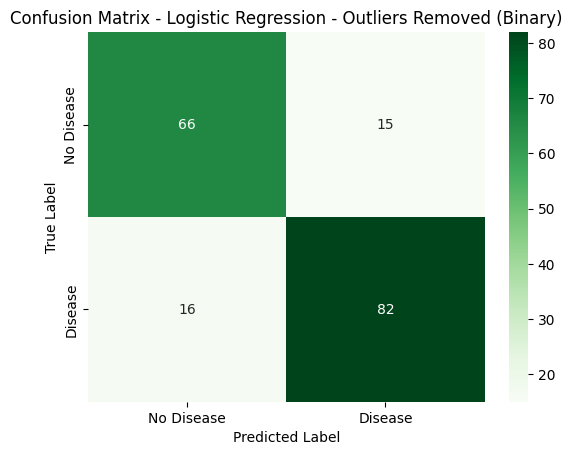

In [ ]:
# Visualise confusion matrix
cm_bin = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_bin,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[
        'No Disease',
        'Disease'
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression - Outliers Removed (Binary)")
plt.show()

Appears to perform slightly worse than the Improved Baseline Model - Binary, most likely due to:
*   Some of the removed outliers may have contained beneficial information
*   The removal of outliers may have had an impact on generalisability
*   Train Score increased: suggesting better fit of training data



### Scale Numerical Columns using StandardScaler (Binary)

In [ ]:
df_scaled_bin = df_outlier_removed_bin.copy()

In [ ]:
# Split X and y as 'num' is target
X = df_scaled_bin.drop(columns=['num'])
y = df_scaled_bin['num']

In [ ]:
# Select numerical columns/features
numeric_col = X.select_dtypes(
    include=numerical_dtype
).columns.tolist()

In [ ]:
# View the columns that are to be scaled
print("Numerical Columns:\n", X[numeric_col])

Numerical Columns:
       age  trestbps   chol  thalch  oldpeak   ca
0    63.0     145.0  233.0   150.0      2.3  0.0
1    67.0     160.0  286.0   108.0      1.5  3.0
3    67.0     120.0  229.0   129.0      2.6  2.0
4    37.0     130.0  250.0   187.0      3.5  0.0
5    41.0     130.0  204.0   172.0      1.4  0.0
..    ...       ...    ...     ...      ...  ...
916  54.0     127.0  333.0   154.0      0.0  0.0
917  62.0     130.0  139.0   140.0      0.5  0.0
919  55.0     122.0  223.0   100.0      0.0  0.0
920  58.0     130.0  385.0   140.0      0.5  0.0
921  62.0     120.0  254.0    93.0      0.0  0.0

[891 rows x 6 columns]


In [ ]:
# Scale numerical columns/features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numeric_col])

In [ ]:
# Create DataFrame from scaled values
df_X_scaled_bin = pd.DataFrame(
    X_scaled,
    columns=numeric_col,
    index=X.index
)

In [ ]:
# Update numerical columns/features with scaled variants
X.update(df_X_scaled_bin)

In [ ]:
# Add 'num' target column back into DataFrame
df_clean_bin = pd.concat([X, y], axis=1)

# Final Clean Dataset (Binary)

In [ ]:
print("Original Dataset:\n")
data

Original Dataset:



,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
918,918,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
919,919,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
920,920,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
print("Cleaned Dataset (Binary):\n")
df_clean_bin

Cleaned Dataset (Binary):



,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,num
0,1.001217,0.761530,0.329159,0.486376,1.358674,-0.365033,True,False,False,False,...,True,True,False,False,False,False,False,False,False,0
1,1.424105,1.639460,0.833911,-1.201260,0.606762,4.348659,True,False,False,False,...,False,False,False,False,True,True,False,True,False,1
3,1.424105,-0.701687,0.291064,-0.357442,1.640641,2.777428,True,False,False,False,...,False,False,False,False,True,True,False,False,True,1
4,-1.747561,-0.116400,0.491060,1.973102,2.486543,-0.365033,True,False,False,False,...,False,False,True,False,False,False,False,True,False,0
5,-1.324672,-0.116400,0.052973,1.370375,0.512773,-0.365033,False,False,False,False,...,False,False,False,False,False,False,True,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,0.049717,-0.291987,1.281522,0.647103,-0.803074,-0.365033,False,False,False,True,...,False,True,False,True,False,True,False,True,False,1
917,0.895494,-0.116400,-0.566063,0.084558,-0.333128,-0.365033,True,False,False,True,...,True,False,False,True,False,True,False,True,False,0
919,0.155439,-0.584630,0.233922,-1.522714,-0.803074,-0.365033,True,False,False,True,...,False,True,False,True,False,True,False,False,False,1
920,0.472606,-0.116400,1.776751,0.084558,-0.333128,-0.365033,True,False,False,True,...,False,True,False,False,False,True,False,True,False,0


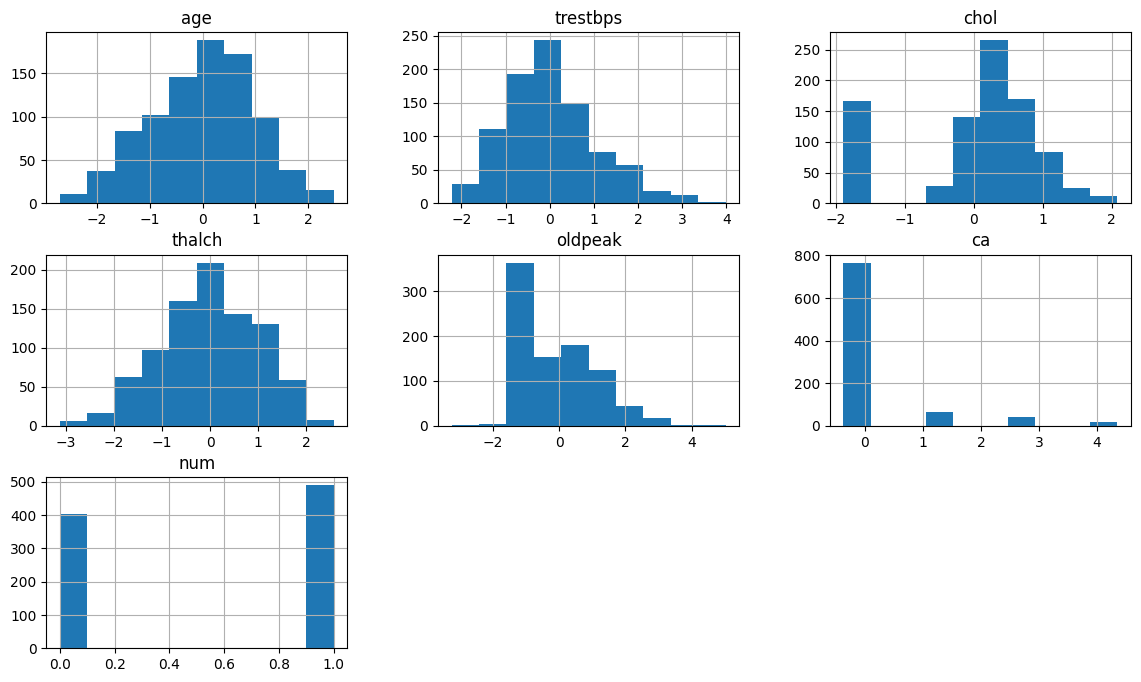

In [ ]:
# Visualise numerical features
df_clean_bin.hist(figsize=(14,8))
plt.show()

### Run Logistic Regression on Cleaned Dataset (Binary)

In [ ]:
# Split X and y
X_clean_bin = df_clean_bin.drop(columns=['num'])
y_clean_bin = df_clean_bin['num']

In [ ]:
print("X_clean_bin Shape:\n", X_clean_bin.shape)
print("y_clean_bin Shape:\n", y_clean_bin.shape)

X_clean_bin Shape:
 (891, 21)
y_clean_bin Shape:
 (891,)


In [ ]:
# Re-split
random_state_tracker += 1
print("random_state used:\n", random_state_tracker)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean_bin,
    y_clean_bin,
    test_size=0.2,
    stratify=y_clean_bin,
    random_state=random_state_tracker
)

random_state used:
 7


In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\n")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (712, 21)
y_train: (712,)


X_test: (179, 21)
y_test: (179,)


In [ ]:
# Train model
lr_liblinear = LogisticRegression(solver='liblinear', max_iter=1000)
lr_liblinear.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
y_pred = lr_liblinear.predict(X_test)

In [ ]:
print("Summary - Logistic Regression - Cleaned Dataset (Binary):")
print(f"Train Score: {lr_liblinear.score(X_train, y_train):.4f}")
print(f"Test Score: {lr_liblinear.score(X_test, y_test):.4f}")

Summary - Logistic Regression - Cleaned Dataset (Binary):
Train Score: 0.8553
Test Score: 0.7933


In [ ]:
# Evaluate model
print("Logistic Regression - Cleaned Dataset - Results (Binary):\n")
print(f"Accuracy: {lr_liblinear.score(X_test, y_test):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Cleaned Dataset - Results (Binary):

Accuracy: 0.7933

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.78      0.77        81
           1       0.81      0.81      0.81        98

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179


Confusion Matrix:

[[63 18]
 [19 79]]


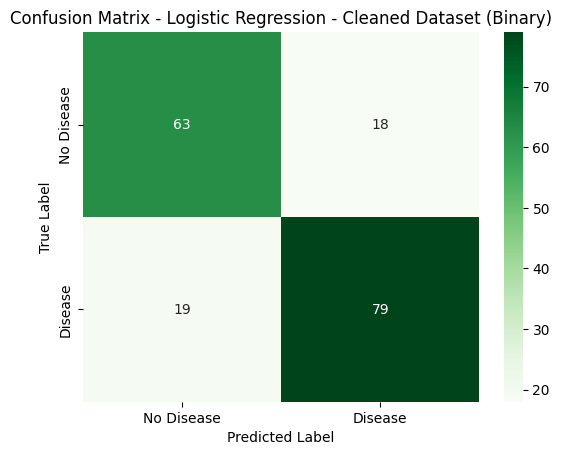

In [ ]:
# Visualise confusion matrix
cm_bin = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_bin,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[
        'No Disease',
        'Disease'
    ],
    yticklabels=[
        "No Disease",
        "Disease"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression - Cleaned Dataset (Binary)")
plt.show()

Performs worse than the Outliers Removed Model - Binary, most likely due to:
*   Scaling causing a loss of magnitude in certain features
*   Therefore, scaling does not appear to improve the Binary Logistic Regression Model
*   Important to note that Train Score increased
*   Increase suggests scaling fit the training set better
*   More overfitting, reduced generalisability




### Visualise Train vs Test Scores per Model
*   Create Python Dictionary of Models, Train/Test Scores
*   Create Pandas DataFrame from Dictionary
*   Model Scores from DataFrame

(Note: Manual Process as no unique variable for each train/test score)

In [ ]:
# Create dictionary of plot data
model_scores = {
    'Model': [
        'Baseline (MC)',
        'Improved Baseline (MC)',
        'Outliers Removed (MC)',
        'Fully Cleaned (MC)',
        'Baseline (B)',
        'Improved Baseline (B)',
        'Outliers Removed (B)',
        'Fully Cleaned (B)'
    ],

    'Train Score': [
        0.6667,
        0.6289,
        0.6194,
        0.6124,
        0.8750,
        0.8365,
        0.8413,
        0.8553
    ],

    'Test Score': [
        0.4833,
        0.5761,
        0.5955,
        0.5843,
        0.8667,
        0.8370,
        0.8268,
        0.7933
    ]
}

In [ ]:
# Create DataFrame of plot data
df_model_scores = pd.DataFrame(model_scores)

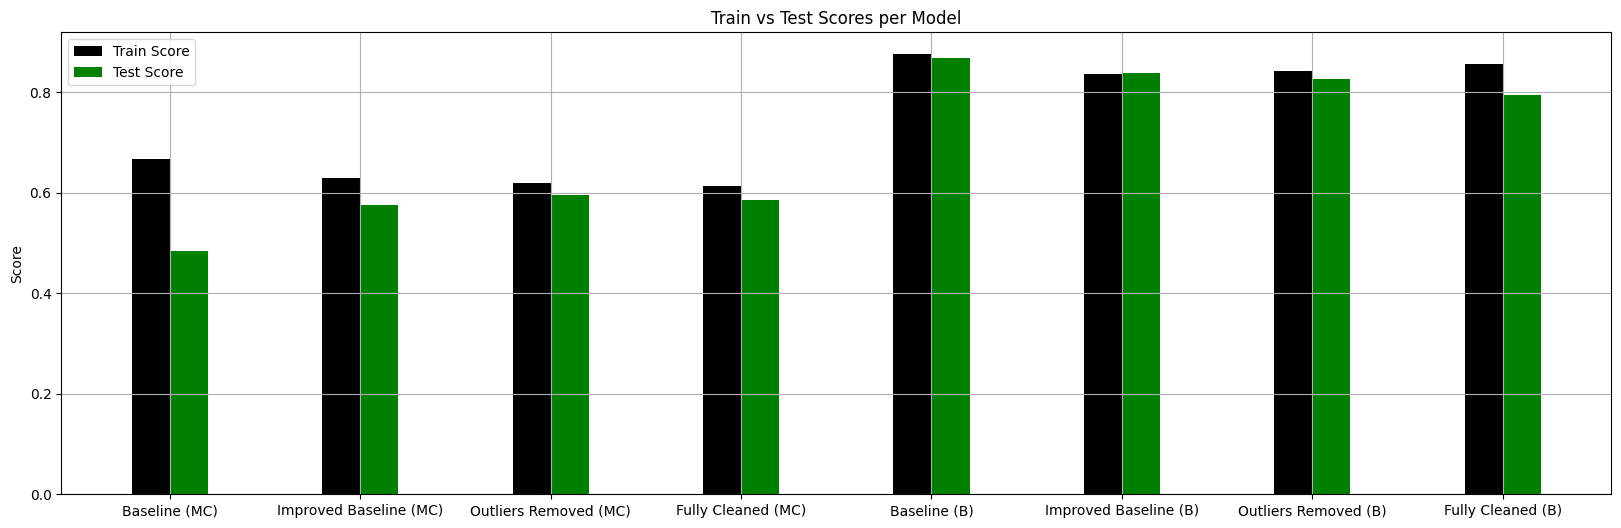

In [ ]:
# Visualise model scores
fig, ax = plt.subplots(figsize=(20, 6))
x = np.arange(len(df_model_scores))

bar_width = 0.2

# Train score
ax.bar(
    x,
    df_model_scores['Train Score'],
    width=bar_width,
    label='Train Score',
    color='black'
)

# Test score
ax.bar(
    x + bar_width,
    df_model_scores['Test Score'],
    width=bar_width,
    label='Test Score',
    color='green'
)

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(df_model_scores['Model'])
ax.set_ylabel('Score')
ax.set_title("Train vs Test Scores per Model")
ax.legend()
plt.grid(True)
plt.show()